In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [2]:
# STEP 2: LOAD DATASET

df = sns.load_dataset("titanic")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# STEP 3: SELECT REQUIRED COLUMNS
df = df[
    [
        "survived",
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked"
    ]
]


In [6]:
# STEP 4: HANDLE MISSING VALUES
df["age"].fillna(
    df["age"].median(),
    inplace=True
)

df["embarked"].fillna(
    df["embarked"].mode()[0],
    inplace=True
)

C:\Users\akshi\AppData\Local\Temp\ipykernel_32524\2130748602.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(


In [7]:
# STEP 5: ENCODE CATEGORICAL DATA
df = pd.get_dummies(
    df,
    columns=["sex", "embarked"],
    drop_first=True
)

print(df.head())

   survived  pclass   age  sibsp  parch     fare  sex_male  embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [8]:
# STEP 6: FEATURES & TARGET
X = df.drop("survived", axis=1)

y = df["survived"]


In [9]:
# STEP 7: TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
# STEP 8: TRAIN MODEL
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
# STEP 9: PREDICTIONS
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]


In [12]:
# STEP 10: EVALUATION
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Accuracy: 0.8100558659217877

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



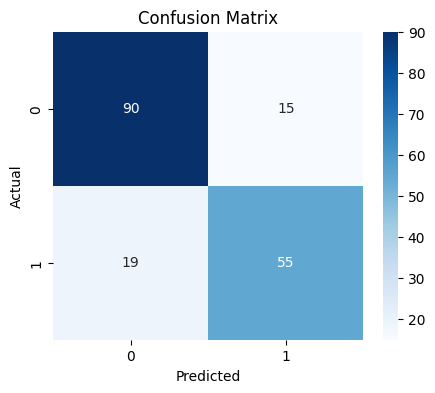

In [13]:
# STEP 11: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

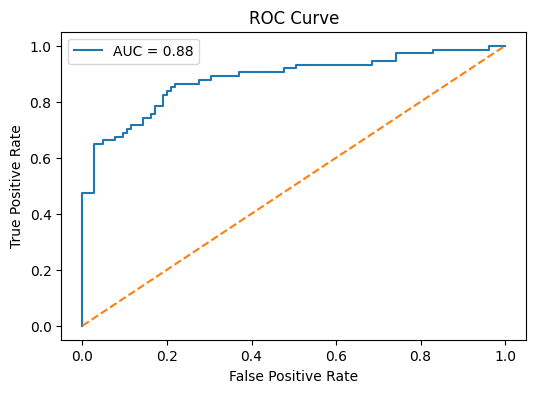

In [14]:
# STEP 12: ROC CURVE
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


In [15]:
# STEP 13: FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(importance_df)

      Feature  Coefficient
0      pclass    -0.937548
1         age    -0.030572
2       sibsp    -0.295612
3       parch    -0.108325
4        fare     0.002584
5    sex_male    -2.592240
6  embarked_Q    -0.113790
7  embarked_S    -0.399913


In [16]:

joblib.dump(model, "titanic_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
